## Data Understanding & Initial Data Cleaning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/credit_risk_loan_prediction.csv")

df.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              32581 non-null  int64  
 1   Age             32581 non-null  int64  
 2   Income          32581 non-null  int64  
 3   Home            32581 non-null  object 
 4   Emp_length      31686 non-null  float64
 5   Intent          32581 non-null  object 
 6   Amount          32581 non-null  int64  
 7   Rate            29465 non-null  float64
 8   Status          32581 non-null  int64  
 9   Percent_income  32581 non-null  float64
 10  Default         32581 non-null  object 
 11  Cred_length     32581 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 3.0+ MB


In [5]:
df.describe()

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,16290.006139,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,9405.479594,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,8145.000000,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,16290.000000,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,24435.000000,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,32780.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.describe(include="object")

,Home,Intent,Default
count,32581,32581,32581
unique,4,6,2
top,RENT,EDUCATION,N
freq,16446,6453,26836


Missing Values

In [7]:
df.isnull().sum()

Id                   0
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64

In [8]:
(df.isnull().sum() / len(df)) * 100

Id                0.000000
Age               0.000000
Income            0.000000
Home              0.000000
Emp_length        2.747000
Intent            0.000000
Amount            0.000000
Rate              9.563856
Status            0.000000
Percent_income    0.000000
Default           0.000000
Cred_length       0.000000
dtype: float64

Duplicates

In [9]:
df.duplicated().sum()

0

Unique Values

In [10]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

Id
32581
----------------------------------------
Age
58
----------------------------------------
Income
4295
----------------------------------------
Home
4
----------------------------------------
Emp_length
36
----------------------------------------
Intent
6
----------------------------------------
Amount
753
----------------------------------------
Rate
348
----------------------------------------
Status
2
----------------------------------------
Percent_income
77
----------------------------------------
Default
2
----------------------------------------
Cred_length
29
----------------------------------------


Examining Target Variable

In [11]:
df["Status"].value_counts()

Status
0    25473
1     7108
Name: count, dtype: int64

In [12]:
df["Status"].value_counts(normalize=True) * 100

Status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Preview each categorical column

In [13]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print("-"*50)

Home
Home
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
--------------------------------------------------
Intent
Intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
--------------------------------------------------
Default
Default
N    26836
Y     5745
Name: count, dtype: int64
--------------------------------------------------


Basic distributions

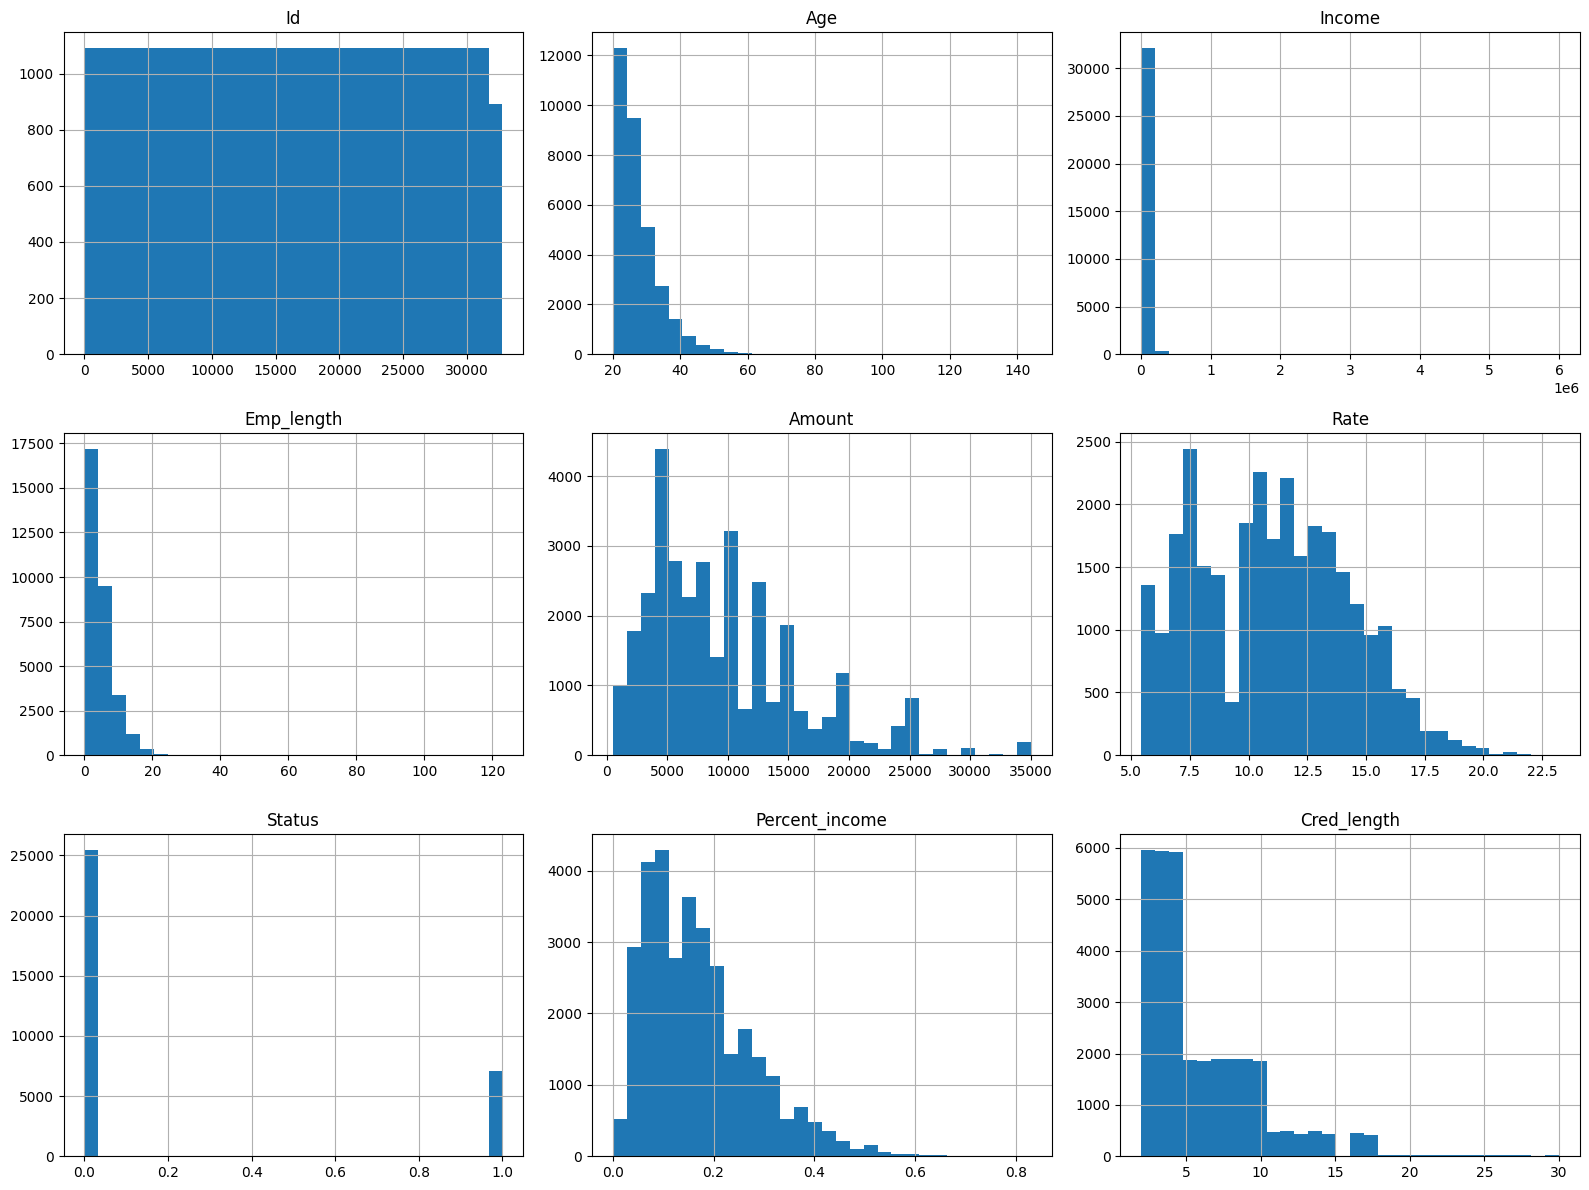

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(16,12),
    bins=30
)

plt.tight_layout()
plt.show()

Checking data types

In [15]:
df.dtypes

Id                  int64
Age                 int64
Income              int64
Home               object
Emp_length        float64
Intent             object
Amount              int64
Rate              float64
Status              int64
Percent_income    float64
Default            object
Cred_length         int64
dtype: object

## Data Quality Assessment

Step 1 — Numerical Summary

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,32581.0,16290.006139,9405.479594,0.00,8145.00,16290.00,24435.00,32780.00
Age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
Income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
Emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
Amount,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
Rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
Status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
Percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
Cred_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


Step 2 — Minimum and Maximum of Each Numeric Column

In [17]:
for col in df.select_dtypes(include=np.number).columns:
    print(f"{col}")
    print(f"Minimum: {df[col].min()}")
    print(f"Maximum: {df[col].max()}")
    print("-"*40)

Id
Minimum: 0
Maximum: 32780
----------------------------------------
Age
Minimum: 20
Maximum: 144
----------------------------------------
Income
Minimum: 4000
Maximum: 6000000
----------------------------------------
Emp_length
Minimum: 0.0
Maximum: 123.0
----------------------------------------
Amount
Minimum: 500
Maximum: 35000
----------------------------------------
Rate
Minimum: 5.42
Maximum: 23.22
----------------------------------------
Status
Minimum: 0
Maximum: 1
----------------------------------------
Percent_income
Minimum: 0.0
Maximum: 0.83
----------------------------------------
Cred_length
Minimum: 2
Maximum: 30
----------------------------------------


Step 3 — Investigating Employment Length

In [18]:
df.sort_values("Emp_length", ascending=False).head(10)

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
210,210,21,192000,MORTGAGE,123.0,VENTURE,20000,6.54,0,0.10,N,4
32355,32355,78,48000,RENT,41.0,MEDICAL,3000,7.51,0,0.06,N,25
32515,32515,53,106000,MORTGAGE,38.0,PERSONAL,20000,9.88,0,0.19,N,23
32428,32428,58,49000,MORTGAGE,34.0,MEDICAL,7500,13.55,1,0.15,Y,24
31866,31866,47,178000,OWN,31.0,VENTURE,9000,10.99,0,0.05,N,17
32263,32263,46,180000,MORTGAGE,31.0,MEDICAL,18000,9.91,0,0.10,N,12
31867,31867,46,180000,MORTGAGE,31.0,VENTURE,18000,9.91,0,0.10,N,11
30914,30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,9000,14.54,0,0.13,N,17
32562,32562,61,160000,MORTGAGE,30.0,PERSONAL,24000,10.38,0,0.15,N,21


Step 4 — Investigating Income

In [19]:
df.sort_values("Income", ascending=False).head(10)

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
32297,32297,144,6000000,MORTGAGE,12.0,PERSONAL,5000,12.73,0,0.00,N,25
30049,30049,42,2039784,RENT,0.0,VENTURE,8450,12.29,0,0.00,Y,15
32546,32546,60,1900000,MORTGAGE,5.0,PERSONAL,1500,NaN,0,0.00,N,21
32497,32497,63,1782000,RENT,13.0,EDUCATION,12025,14.27,0,0.01,N,30
31924,31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,6400,7.40,0,0.00,N,15
31922,31922,47,1362000,MORTGAGE,9.0,VENTURE,6600,7.74,0,0.00,N,17
17833,17833,32,1200000,MORTGAGE,1.0,VENTURE,12000,7.51,0,0.01,N,8
29120,29120,40,1200000,MORTGAGE,1.0,MEDICAL,10000,NaN,0,0.01,N,16
29119,29119,36,1200000,OWN,16.0,MEDICAL,10000,6.54,0,0.01,N,11
17834,17834,34,948000,MORTGAGE,18.0,PERSONAL,2000,9.99,0,0.00,N,7


Insight: We Retain high-income observations because they appear to be valid and consistent.

Step 5 — Checking Age

In [20]:
df["Age"].describe()

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: Age, dtype: float64

In [21]:
df.sort_values("Age").head(10)

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
1313,1313,20,64000,RENT,3.0,VENTURE,16000,15.31,1,0.25,Y,4
12943,12943,20,85920,MORTGAGE,3.0,DEBTCONSOLIDATION,12000,8.49,0,0.14,N,2
14827,14827,20,115731,MORTGAGE,4.0,DEBTCONSOLIDATION,9625,10.74,0,0.08,N,3
15830,15830,20,188004,MORTGAGE,4.0,EDUCATION,2000,8.59,0,0.01,N,4
11902,11902,20,77052,MORTGAGE,4.0,EDUCATION,24250,11.36,0,0.31,N,2
15417,15417,20,135000,MORTGAGE,1.0,VENTURE,15000,15.96,0,0.11,Y,2
7327,7327,20,42000,RENT,4.0,VENTURE,6500,11.71,0,0.15,N,2
17196,17196,20,65000,MORTGAGE,4.0,VENTURE,4800,9.99,0,0.07,N,4
16339,16339,20,188004,MORTGAGE,4.0,PERSONAL,2000,8.59,0,0.01,N,2
13918,13918,20,98000,MORTGAGE,4.0,EDUCATION,24250,NaN,0,0.25,N,4


In [22]:
df.sort_values("Age", ascending=False).head(10)

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
81,81,144,250000,RENT,4.0,VENTURE,4800,13.57,0,0.02,N,3
32297,32297,144,6000000,MORTGAGE,12.0,PERSONAL,5000,12.73,0,0.00,N,25
183,183,144,200000,MORTGAGE,4.0,EDUCATION,6000,11.86,0,0.03,N,2
747,747,123,78000,RENT,7.0,VENTURE,20000,NaN,0,0.26,N,4
575,575,123,80004,RENT,2.0,EDUCATION,20400,10.25,0,0.25,N,3
32416,32416,94,24000,RENT,1.0,MEDICAL,6500,NaN,0,0.27,N,27
32506,32506,84,94800,MORTGAGE,2.0,PERSONAL,10000,7.51,0,0.11,N,24
32422,32422,80,64000,RENT,7.0,MEDICAL,6800,11.71,0,0.11,N,25
32355,32355,78,48000,RENT,41.0,MEDICAL,3000,7.51,0,0.06,N,25
32534,32534,76,75000,RENT,23.0,MEDICAL,15000,8.94,0,0.20,N,25


Insight: No bank is issuing personal loans to people aged 123 or 144.

Step 6 — Loan Interest Rate

In [23]:
df["Rate"].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: Rate, dtype: float64

Step 7 — Percent of Income

Since this represents:

Loan Amount / Income

it should normally be less than 1.

In [24]:
df["Percent_income"].describe()

count    32581.000000
mean         0.170203
std          0.106782
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: Percent_income, dtype: float64

Insight: Acceptable. Nobody is borrowing more than their annual income.

In [25]:
df[df["Percent_income"] > 1]

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length


Step 8 — Negative Values

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    negatives = (df[col] < 0).sum()
    print(col, negatives)

Id 0
Age 0
Income 0
Emp_length 0
Amount 0
Rate 0
Status 0
Percent_income 0
Cred_length 0


Removing impossible ages

Banks usually consider working-age adults.
So we can filter: Age between 18 and 100
Everything above 100 is obviously invalid.

In [27]:
df = df[df["Age"] <= 100]

Insight: Removed 5 records with impossible ages (>100 years).

Removing impossible employment lengths

Someone could theoretically start working at 18 and retire around 78.

60 years of employment is already extremely generous.

In [28]:
df = df[df["Emp_length"] <= 60]

Insight: Removed 2 records with impossible employment lengths (>60 years).

Filling missing employment length

Since only 2.7% is missing, We use Median

In [29]:
df["Emp_length"] = df["Emp_length"].fillna(df["Emp_length"].median())

Filling missing Rate

In [30]:
df["Rate"] = df["Rate"].fillna(df["Rate"].median())

## Data Cleaning

In [31]:
# Remove impossible ages
df = df[df["Age"] <= 100]

# Remove impossible employment lengths
df = df[df["Emp_length"] <= 60]

# Fill missing Employment Length
df["Emp_length"] = df["Emp_length"].fillna(df["Emp_length"].median())

# Fill missing Interest Rate
df["Rate"] = df["Rate"].fillna(df["Rate"].median())

# Verify remaining missing values
df.isnull().sum()

Id                0
Age               0
Income            0
Home              0
Emp_length        0
Intent            0
Amount            0
Rate              0
Status            0
Percent_income    0
Default           0
Cred_length       0
dtype: int64

In [32]:
print(df.shape)

(31679, 12)


## Exploratory Data Analysis (EDA)

Step 1 — Examining the Categorical Variables
Home Ownership

In [33]:
home_default = pd.crosstab(
    df["Home"],
    df["Status"],
    normalize="index"
) * 100

home_default

Status,0,1
Home,,
MORTGAGE,87.547746,12.452254
OTHER,69.158879,30.841121
OWN,93.070539,6.929461
RENT,68.921105,31.078895


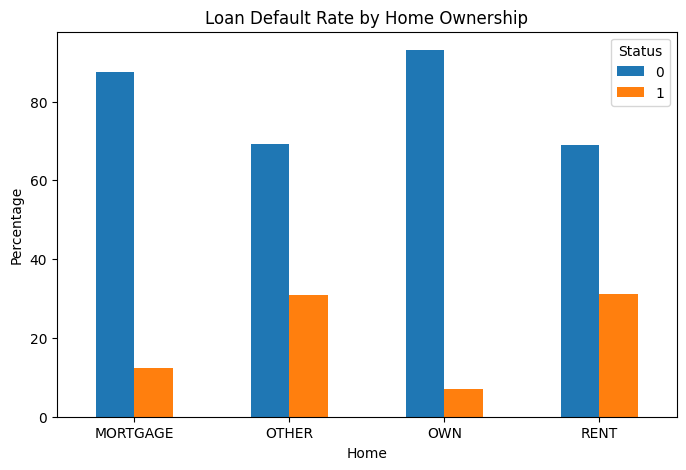

In [34]:
home_default.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loan Default Rate by Home Ownership")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

Insight: Home ownership often reflects financial stability. Borrowers who own homes or have mortgages may exhibit lower default rates than renters.

Step 2 — Loan Intent

In [35]:
intent_default = pd.crosstab(
    df["Intent"],
    df["Status"],
    normalize="index"
) * 100

intent_default

Status,0,1
Intent,,
DEBTCONSOLIDATION,71.623223,28.376777
EDUCATION,83.047074,16.952926
HOMEIMPROVEMENT,74.444444,25.555556
MEDICAL,73.461082,26.538918
PERSONAL,80.510527,19.489473
VENTURE,85.341257,14.658743


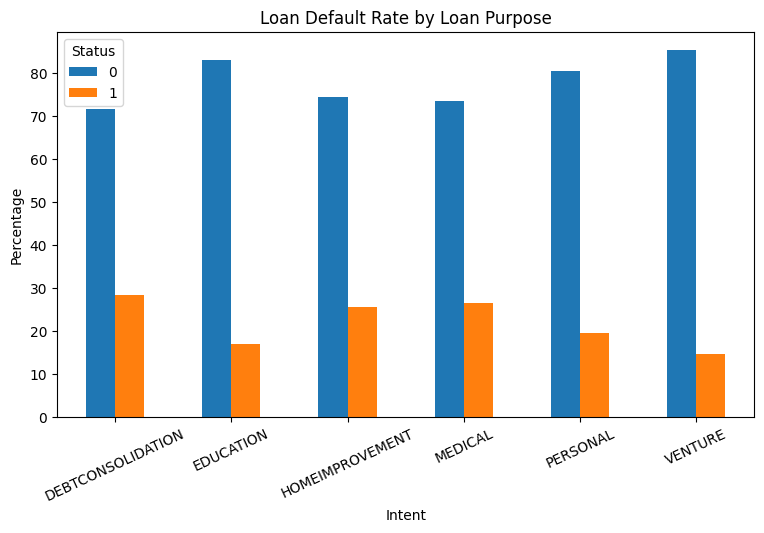

In [36]:
intent_default.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Loan Default Rate by Loan Purpose")

plt.ylabel("Percentage")

plt.xticks(rotation=25)

plt.show()

Insight: Certain loan purposes (such as debt consolidation or personal loans) may carry greater financial risk than educational or home improvement loans.

Step 3 — Previous Default History

In [37]:
default_history = pd.crosstab(
    df["Default"],
    df["Status"],
    normalize="index"
) * 100

default_history

Status,0,1
Default,,
N,81.916241,18.083759
Y,62.437811,37.562189


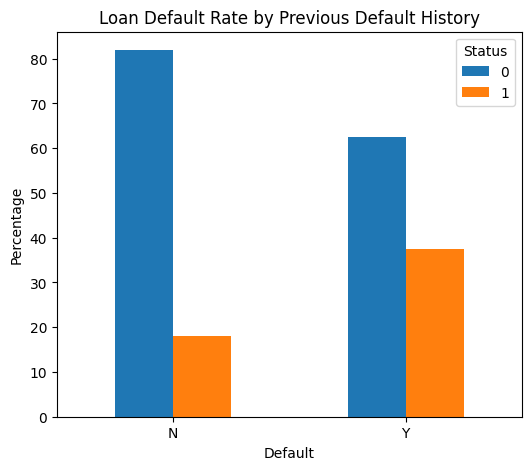

In [38]:
default_history.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Loan Default Rate by Previous Default History")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

Step 4 — Numerical Variables

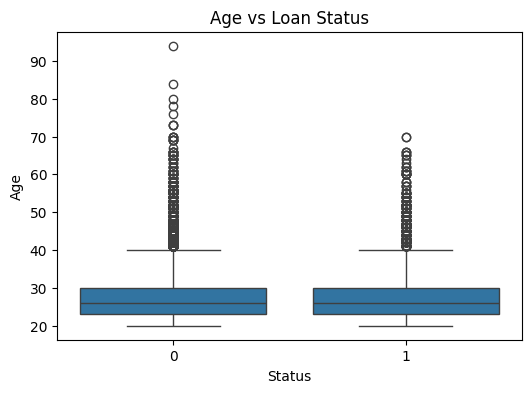

In [39]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Status",
    y="Age"
)

plt.title("Age vs Loan Status")

plt.show()

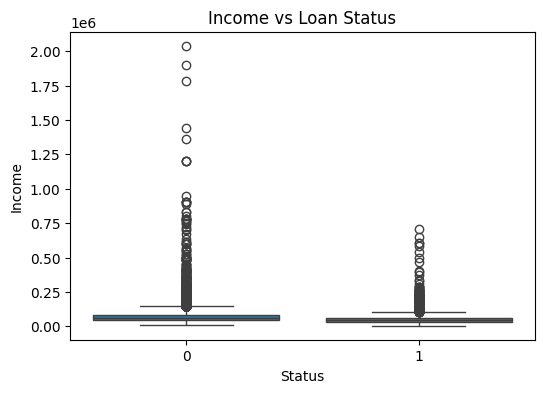

In [40]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Status",
    y="Income"
)

plt.title("Income vs Loan Status")

plt.show()

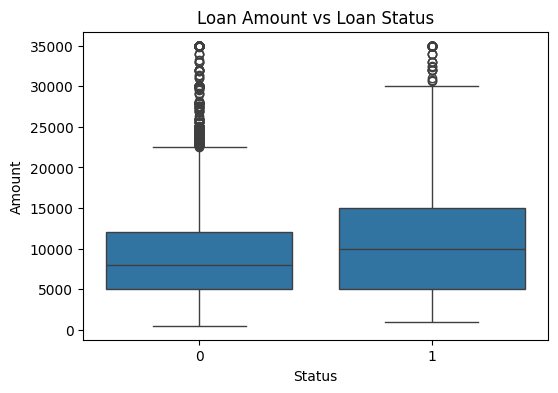

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Status",
    y="Amount"
)

plt.title("Loan Amount vs Loan Status")

plt.show()

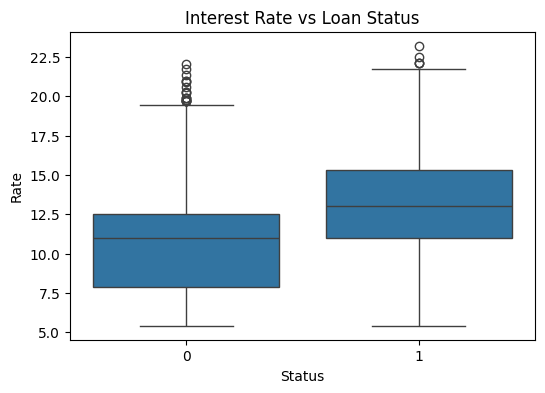

In [42]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Status",
    y="Rate"
)

plt.title("Interest Rate vs Loan Status")

plt.show()

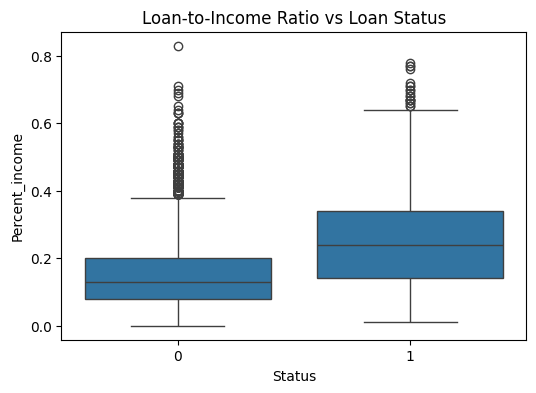

In [43]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Status",
    y="Percent_income"
)

plt.title("Loan-to-Income Ratio vs Loan Status")

plt.show()

Step 5 — Correlation Matrix

In [44]:
df_corr = df.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ["Home", "Intent", "Default"]:
    df_corr[col] = encoder.fit_transform(df_corr[col])

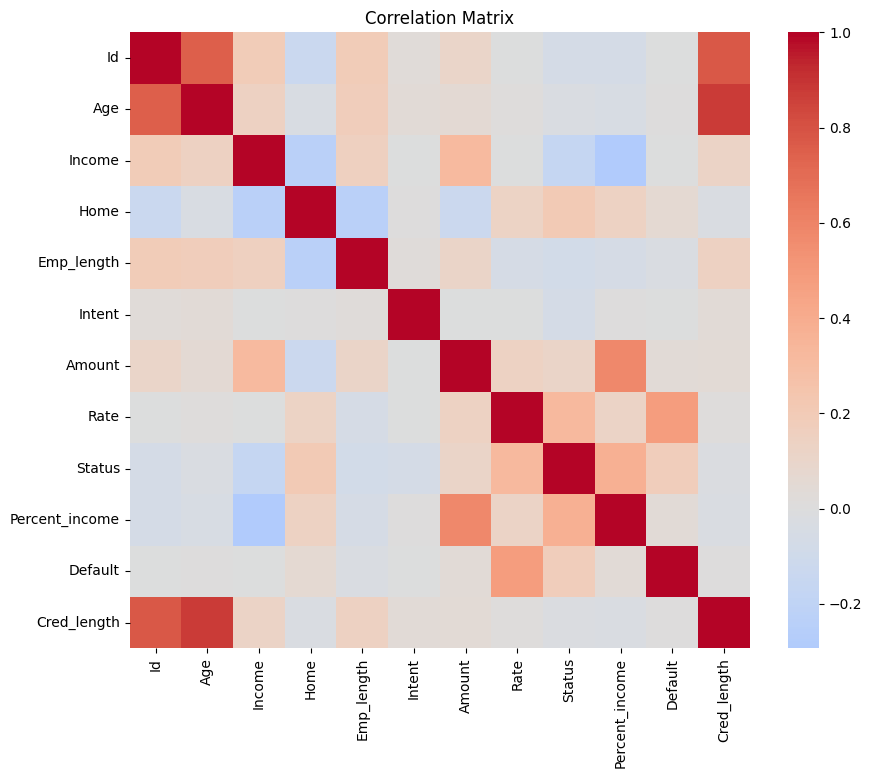

In [45]:
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

Step 6 — Correlation with Target

In [46]:
corr_target = (
    corr["Status"]
    .sort_values(ascending=False)
)

corr_target

Status            1.000000
Percent_income    0.379823
Rate              0.323247
Home              0.208801
Default           0.181090
Amount            0.112188
Cred_length      -0.016830
Age              -0.022130
Id               -0.062469
Intent           -0.065494
Emp_length       -0.085966
Income           -0.164128
Name: Status, dtype: float64

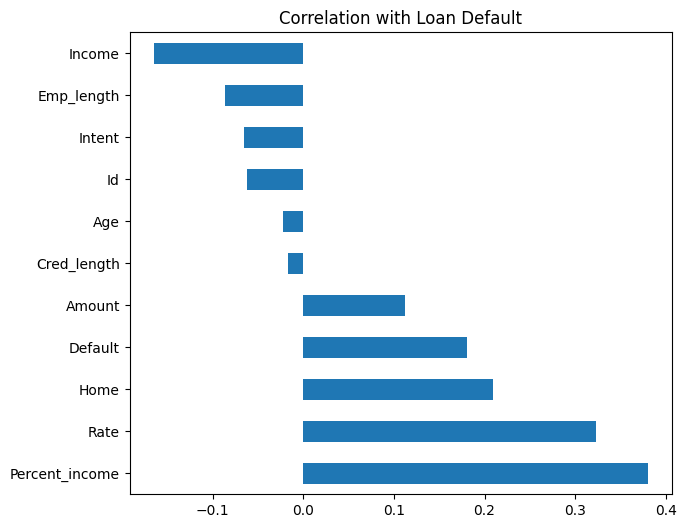

In [47]:
corr_target.drop("Status").plot(
    kind="barh",
    figsize=(7,6)
)

plt.title("Correlation with Loan Default")

plt.show()

In [48]:
top_features = (
    corr["Status"]
    .drop("Status")
    .abs()
    .sort_values(ascending=False)
)

top_features

Percent_income    0.379823
Rate              0.323247
Home              0.208801
Default           0.181090
Income            0.164128
Amount            0.112188
Emp_length        0.085966
Intent            0.065494
Id                0.062469
Age               0.022130
Cred_length       0.016830
Name: Status, dtype: float64

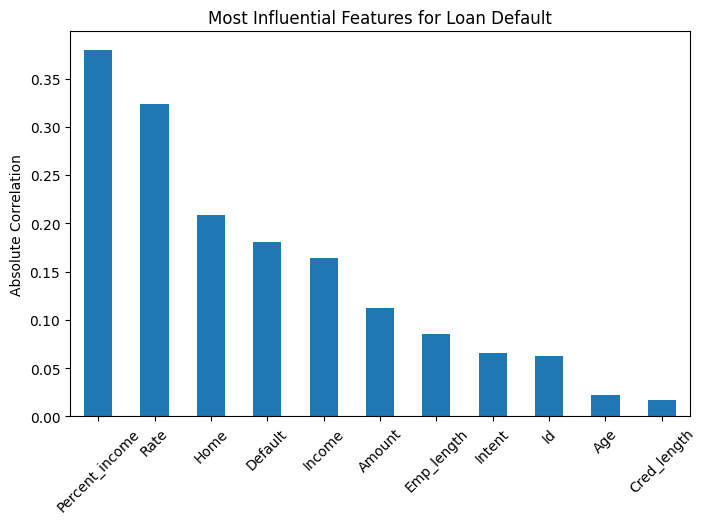

In [49]:
plt.figure(figsize=(8,5))

top_features.plot(kind="bar")

plt.title("Most Influential Features for Loan Default")

plt.ylabel("Absolute Correlation")

plt.xticks(rotation=45)

plt.show()

## Feature Engineering & Machine Learning

Step 1 — Preparing the Dataset

In [50]:
# Creating a copy for machine learning

df_ml = df.copy()

Step 2 — Encoding Categorical Variables

In [51]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "Home",
    "Intent",
    "Default"
]

for col in categorical_columns:
    df_ml[col] = label_encoder.fit_transform(df_ml[col])

In [52]:
df_ml.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
1,1,21,9600,2,5.0,1,1000,11.14,0,0.10,0,2
2,2,25,9600,0,1.0,3,5500,12.87,1,0.57,0,3
3,3,23,65500,3,4.0,3,35000,15.23,1,0.53,0,2
4,4,24,54400,3,8.0,3,35000,14.27,1,0.55,1,4
5,5,21,9900,2,2.0,5,2500,7.14,1,0.25,0,2


Step 3 — Separating Features and Target

In [53]:
X = df_ml.drop(
    columns=[
        "Status",
        "Id"
    ]
)

y = df_ml["Status"]

In [54]:
print(X.shape)

(31679, 10)


Step 4 — Train/Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(25343, 10)
(6336, 10)
(25343,)
(6336,)


Step 5 — Checking Class Balance

In [57]:
print(y_train.value_counts())

print()

print(
    y_train.value_counts(normalize=True) * 100
)

Status
0    19883
1     5460
Name: count, dtype: int64

Status
0    78.455589
1    21.544411
Name: proportion, dtype: float64


Step 6 — Ready for Modeling

In [58]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Training Logistic Regression

In [59]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [60]:
y_pred = log_model.predict(X_test)

y_prob = log_model.predict_proba(X_test)[:,1]

Creating an Evaluation Function

In [61]:
def evaluate_model(model_name, y_true, y_pred, y_prob):

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix\n")

    print(cm)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

Evaluating Logistic Regression

In [62]:
log_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

Logistic Regression
Accuracy : 0.8253
Precision: 0.6792
Recall   : 0.3582
F1 Score : 0.4691
ROC AUC  : 0.8188

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.95      0.90      4971
           1       0.68      0.36      0.47      1365

    accuracy                           0.83      6336
   macro avg       0.76      0.66      0.68      6336
weighted avg       0.81      0.83      0.80      6336


Confusion Matrix

[[4740  231]
 [ 876  489]]


Insight:

The Logistic Regression model achieved 82.5% accuracy and an ROC AUC of 0.818, indicating good overall discrimination between default and non-default borrowers.

The model showed high precision (67.9%), meaning that most borrowers predicted to default actually did.

However, the recall was only 35.8%, indicating that many actual defaults were missed.

In a banking context, improving recall is desirable because identifying high-risk borrowers is often more important than maximizing overall accuracy.

Step 1 — Decision Tree Classifier

In [63]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [65]:
tree_pred = tree_model.predict(X_test)

tree_prob = tree_model.predict_proba(X_test)[:,1]

In [66]:
tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred,
    tree_prob
)

Decision Tree
Accuracy : 0.9149
Precision: 0.9394
Recall   : 0.6469
F1 Score : 0.7662
ROC AUC  : 0.8938

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      4971
           1       0.94      0.65      0.77      1365

    accuracy                           0.91      6336
   macro avg       0.93      0.82      0.86      6336
weighted avg       0.92      0.91      0.91      6336


Confusion Matrix

[[4914   57]
 [ 482  883]]


Step 2 — Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [69]:
forest_pred = forest_model.predict(X_test)

forest_prob = forest_model.predict_proba(X_test)[:,1]

In [70]:
forest_results = evaluate_model(
    "Random Forest",
    y_test,
    forest_pred,
    forest_prob
)

Random Forest
Accuracy : 0.9115
Precision: 0.9579
Recall   : 0.6161
F1 Score : 0.7499
ROC AUC  : 0.9129

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.99      0.95      4971
           1       0.96      0.62      0.75      1365

    accuracy                           0.91      6336
   macro avg       0.93      0.80      0.85      6336
weighted avg       0.92      0.91      0.90      6336


Confusion Matrix

[[4934   37]
 [ 524  841]]


Step 3 — Comparing Models

In [71]:
import pandas as pd

results = pd.DataFrame([
    log_results,
    tree_results,
    forest_results
])

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.825284,0.679167,0.358242,0.469065,0.818802
1,Decision Tree,0.914931,0.939362,0.646886,0.766161,0.893827
2,Random Forest,0.911458,0.957859,0.616117,0.749889,0.912861


In [72]:
results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8253,0.6792,0.3582,0.4691,0.8188
1,Decision Tree,0.9149,0.9394,0.6469,0.7662,0.8938
2,Random Forest,0.9115,0.9579,0.6161,0.7499,0.9129


Step 4 — Feature Importance

In [73]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,Percent_income,0.333386
6,Rate,0.210595
2,Home,0.155623
1,Income,0.143484
5,Amount,0.048872
4,Intent,0.041670
3,Emp_length,0.029997
8,Default,0.023877
0,Age,0.007237
9,Cred_length,0.005261


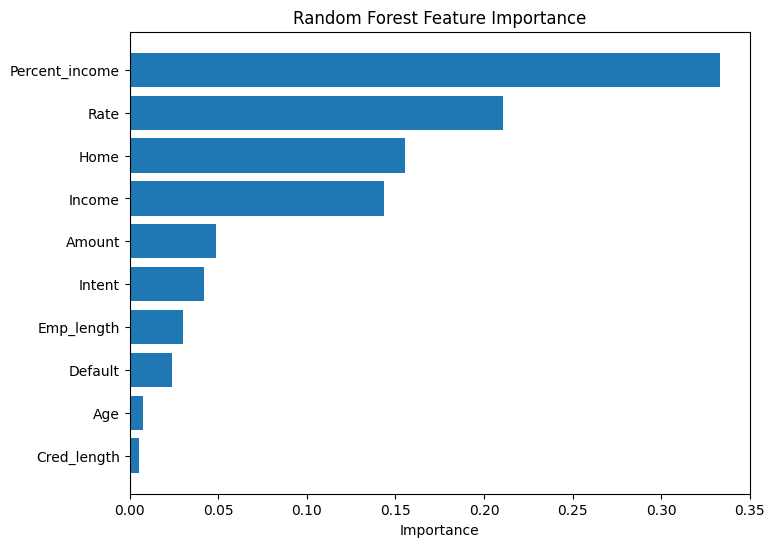

In [74]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Three machine learning models were trained and evaluated using Accuracy, Precision, Recall, F1 Score, and ROC AUC. Logistic Regression provided an interpretable baseline, while Decision Tree and Random Forest captured more complex relationships. Model comparison was used to identify the best-performing algorithm for predicting loan default risk.

## Exporting Model Comparison

In [75]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

## Exporting Feature Importance

In [76]:
importance.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

## Exporting Confusion Matrices

Logistic Regression

In [77]:
cm_log = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual 0","Actual 1"],
    columns=["Predicted 0","Predicted 1"]
)

cm_log.to_csv(
    "../outputs/confusion_logistic.csv"
)

Decision Tree

In [78]:
cm_tree = pd.DataFrame(
    confusion_matrix(y_test, tree_pred),
    index=["Actual 0","Actual 1"],
    columns=["Predicted 0","Predicted 1"]
)

cm_tree.to_csv(
    "../outputs/confusion_tree.csv"
)

Random Forest

In [79]:
cm_rf = pd.DataFrame(
    confusion_matrix(y_test, forest_pred),
    index=["Actual 0","Actual 1"],
    columns=["Predicted 0","Predicted 1"]
)

cm_rf.to_csv(
    "../outputs/confusion_random_forest.csv"
)

## Step 5 — Exporting Predictions

In [80]:
predictions = X_test.copy()

predictions["Actual Status"] = y_test.values

predictions["Predicted Status"] = forest_pred

predictions["Probability of Default"] = forest_prob

predictions.to_csv(
    "../outputs/predictions.csv",
    index=False
)

## Exporting the Final Clean Dataset

In [81]:
df.to_csv(
    "../data/processed/clean_credit_risk.csv",
    index=False
)

## Step 1 — Creating the Database (SQL)

In [82]:
import sqlite3
import pandas as pd

In [83]:
conn = sqlite3.connect(
    "../data/processed/credit_risk.db"
)

In [84]:
df = pd.read_csv(
    "../data/processed/clean_credit_risk.csv"
)

In [85]:
df.to_sql(
    "credit_risk",
    conn,
    if_exists="replace",
    index=False
)

31679

In [86]:
pd.read_sql(
    "SELECT COUNT(*) FROM credit_risk;",
    conn
)

,COUNT(*)
0,31679


In [87]:
with open("../sql/basic_queries.sql", "r") as file:
    sql_script = file.read()

for statement in sql_script.split(";"):
    if statement.strip():
        print(pd.read_sql(statement, conn))

   total_loans
0        31679
   average_age
0    27.730673
   average_income
0    66490.099182
   average_loan
0   9659.962436
   average_interest_rate
0              11.034921
   Status  borrowers
0       0      24854
1       1       6825
       Home  borrowers
0  MORTGAGE      13090
1     OTHER        107
2       OWN       2410
3      RENT      16072
              Intent  borrowers
0  DEBTCONSOLIDATION       5064
1          EDUCATION       6288
2    HOMEIMPROVEMENT       3510
3            MEDICAL       5897
4           PERSONAL       5367
5            VENTURE       5553


In [89]:
with open("../sql/risk_analysis.sql", "r") as file:
    sql_script = file.read()

for statement in sql_script.split(";"):
    if statement.strip():
        print(pd.read_sql(statement, conn))

              Intent  average_rate
0    HOMEIMPROVEMENT     11.204858
1            MEDICAL     11.070256
2  DEBTCONSOLIDATION     11.019226
3           PERSONAL     11.016823
4          EDUCATION     10.983251
5            VENTURE     10.980295
       Home  debt_ratio
0     OTHER    0.191963
1       OWN    0.186598
2      RENT    0.181901
3  MORTGAGE    0.151209
   Age  borrowers
0   23       3774
1   22       3518
2   24       3455
3   25       2952
4   26       2420
5   27       2095
6   28       1805
7   29       1646
8   30       1266
9   21       1177
     Income  Status
0   2039784       0
1   1900000       0
2   1782000       0
3   1440000       0
4   1362000       0
5   1200000       0
6   1200000       0
7   1200000       0
8    948000       0
9    900000       0
10   900000       0
11   900000       0
12   900000       0
13   889000       0
14   828000       0
15   828000       0
16   800000       0
17   780000       0
18   780000       0
19   780000       0
    Amount   Rate

## Business Queries

In [92]:
query = """
SELECT
Home,
ROUND(AVG(Status)*100,2) AS default_rate
FROM credit_risk
GROUP BY Home
ORDER BY default_rate DESC;
"""

pd.read_sql(query, conn)

,Home,default_rate
0,RENT,31.08
1,OTHER,30.84
2,MORTGAGE,12.45
3,OWN,6.93


In [93]:
query = """
SELECT
Intent,
ROUND(AVG(Status)*100,2) AS default_rate
FROM credit_risk
GROUP BY Intent
ORDER BY default_rate DESC;
"""

pd.read_sql(query, conn)

,Intent,default_rate
0,DEBTCONSOLIDATION,28.38
1,MEDICAL,26.54
2,HOMEIMPROVEMENT,25.56
3,PERSONAL,19.49
4,EDUCATION,16.95
5,VENTURE,14.66


In [105]:
query = """
SELECT
"Default",
ROUND(AVG(Status)*100,2) AS default_rate
FROM credit_risk
GROUP BY "Default";
"""

pd.read_sql(query, conn)

,Default,default_rate
0,N,18.08
1,Y,37.56


In [95]:
query = """
SELECT
ROUND(AVG(Percent_income),2)
AS average_debt_ratio
FROM credit_risk;
"""

pd.read_sql(query, conn)

,average_debt_ratio
0,0.17


In [96]:
query = """
SELECT
ROUND(AVG(Income),0)
AS average_income
FROM credit_risk
WHERE Status=1;
"""

pd.read_sql(query, conn)

,average_income
0,49963.0


In [97]:
query = """
SELECT
ROUND(AVG(Income),0)
AS average_income
FROM credit_risk
WHERE Status=0;
"""

pd.read_sql(query, conn)

,average_income
0,71029.0


## Model Metrics

In [106]:
cursor = conn.cursor()

cursor.executescript("""
DROP TABLE IF EXISTS model_metrics;

CREATE TABLE model_metrics (

Model TEXT,
Accuracy REAL,
Precision REAL,
Recall REAL,
F1 REAL,
ROC_AUC REAL

);

INSERT INTO model_metrics VALUES
('Logistic Regression',0.8253,0.6792,0.3582,0.4691,0.8188);

INSERT INTO model_metrics VALUES
('Decision Tree',0.9149,0.9394,0.6469,0.7662,0.8938);

INSERT INTO model_metrics VALUES
('Random Forest',0.9115,0.9579,0.6161,0.7499,0.9129);
""")

conn.commit()

In [107]:
query = """
SELECT *
FROM model_metrics
ORDER BY ROC_AUC DESC;
"""

pd.read_sql(query, conn)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.9115,0.9579,0.6161,0.7499,0.9129
1,Decision Tree,0.9149,0.9394,0.6469,0.7662,0.8938
2,Logistic Regression,0.8253,0.6792,0.3582,0.4691,0.8188


## Advanced Queries

In [99]:
query = """
SELECT
Home,
Intent,
COUNT(*) AS borrowers,
ROUND(AVG(Status)*100,2) AS default_rate
FROM credit_risk
GROUP BY Home, Intent
ORDER BY default_rate DESC;
"""

pd.read_sql(query, conn)

,Home,Intent,borrowers,default_rate
0,OTHER,DEBTCONSOLIDATION,17,47.06
1,OTHER,PERSONAL,18,44.44
2,RENT,HOMEIMPROVEMENT,1499,42.29
3,OTHER,MEDICAL,17,41.18
4,OWN,DEBTCONSOLIDATION,68,36.76
5,RENT,DEBTCONSOLIDATION,2740,35.51
6,OTHER,EDUCATION,17,35.29
7,RENT,MEDICAL,3343,31.77
8,RENT,PERSONAL,2660,30.64
9,RENT,VENTURE,2606,26.09


In [104]:
query = """
SELECT
"Default",
Home,
COUNT(*) AS borrowers
FROM credit_risk
GROUP BY "Default", Home;
"""

pd.read_sql(query, conn)

,Default,Home,borrowers
0,N,MORTGAGE,11120
1,N,OTHER,78
2,N,OWN,1986
3,N,RENT,12867
4,Y,MORTGAGE,1970
5,Y,OTHER,29
6,Y,OWN,424
7,Y,RENT,3205


In [101]:
query = """
SELECT
Intent,
ROUND(AVG(Amount),0) AS average_loan,
ROUND(AVG(Income),0) AS average_income
FROM credit_risk
GROUP BY Intent;
"""

pd.read_sql(query, conn)

,Intent,average_loan,average_income
0,DEBTCONSOLIDATION,9670.0,67005.0
1,EDUCATION,9521.0,64626.0
2,HOMEIMPROVEMENT,10449.0,74312.0
3,MEDICAL,9351.0,62095.0
4,PERSONAL,9644.0,67503.0
5,VENTURE,9653.0,66876.0


In [102]:
query = """
SELECT
Status,
ROUND(AVG(Rate),2) AS average_interest,
ROUND(AVG(Percent_income),2) AS debt_ratio
FROM credit_risk
GROUP BY Status;
"""

pd.read_sql(query, conn)

,Status,average_interest,debt_ratio
0,0,10.51,0.15
1,1,12.93,0.25


## Creating a Business Insights Table

In [112]:
business_insights = {
    "Insight": [

        "Total Loans",
        "Default Rate",
        "Average Borrower Age",
        "Average Loan Amount",
        "Highest Risk Home Ownership",
        "Highest Risk Loan Purpose",
        "Previous Default Risk",
        "Most Important Risk Factor",
        "Recommended Machine Learning Model",
        "Best Model ROC AUC"

    ],

    "Value": [

        len(df),

        f"{df['Status'].mean()*100:.2f}%",

        round(df["Age"].mean(),1),

        f"${df['Amount'].mean():,.0f}",

        "RENT (31.1% Default Rate)",

        "Debt Consolidation (28.4% Default Rate)",

        "37.6% Default Rate",

        "Loan-to-Income Ratio (31.7% Feature Importance)",

        "Random Forest",

        "0.9129"

    ]
}

business_df = pd.DataFrame(business_insights)

In [113]:
business_df.to_csv(
    "../outputs/business_insights.csv",
    index=False
)

## Creating a Recommendations Table

In [110]:
recommendations = {
    "Recommendation":[

        "Monitor borrowers with high loan-to-income ratios",

        "Apply stricter reviews for debt consolidation loans",

        "Review applications from renters more carefully",

        "Consider previous default history in underwriting",

        "Use Random Forest for automated risk scoring"

    ]
}

recommendations = pd.DataFrame(recommendations)

In [111]:
recommendations.to_csv(
    "../outputs/business_recommendations.csv",
    index=False
)

In [114]:
loan_intent_summary = (
    df.groupby("Intent")
      .agg(
          Loans=("Status", "count"),
          Default_Rate=("Status", "mean")
      )
      .reset_index()
)

loan_intent_summary["Default_Rate"] = (
    loan_intent_summary["Default_Rate"] * 100
).round(2)

loan_intent_summary

,Intent,Loans,Default_Rate
0,DEBTCONSOLIDATION,5064,28.38
1,EDUCATION,6288,16.95
2,HOMEIMPROVEMENT,3510,25.56
3,MEDICAL,5897,26.54
4,PERSONAL,5367,19.49
5,VENTURE,5553,14.66


In [115]:
loan_intent_summary.to_csv(
    "../outputs/loan_intent_summary.csv",
    index=False
)

In [116]:
import joblib

In [117]:
joblib.dump(
    forest_model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']